## Download Fashion Dataset from Kaggle

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/fashion-product-images-small


In [4]:
import os

dataset=os.path.join(path,'images')

In [5]:
dataset

'/kaggle/input/fashion-product-images-small/images'

## Installations

In [8]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121  # (for CUDA 12.x)
!pip install transformers accelerate
!pip install scikit-learn matplotlib tqdm pillow numpy
!pip install kneed

Looking in indexes: https://download.pytorch.org/whl/cu121


## Import Libraries

In [9]:
import os
import torch
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from transformers import AutoModel, AutoImageProcessor
from torchvision import transforms


## Load Dinov2 model

In [10]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "facebook/dinov2-base"
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE) 
model.eval()

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06,

## Load Images

In [11]:
def load_images(image_dir, limit=None):
    paths = [os.path.join(image_dir, f) for f in os.listdir(image_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if limit:
        paths = paths[:limit]
    return paths

image_paths = load_images(dataset)
print(f"Loaded {len(image_paths)} images.")


Loaded 44441 images.


## Extract DINOv2 Embeddings

In [12]:
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
VIS_SAMPLE_COUNT = 10  # number of random images to save patch embeddings for

all_embeddings = []
patch_embeddings = {}
os.makedirs("outputs", exist_ok=True)

# Random subset for visualization
sample_paths_for_vis = set(random.sample(image_paths, min(VIS_SAMPLE_COUNT, len(image_paths))))

for i in tqdm(range(0, len(image_paths), BATCH_SIZE), desc="Extracting embeddings"):
    batch_paths = image_paths[i:i+BATCH_SIZE]
    images = [Image.open(p).convert("RGB") for p in batch_paths]
    inputs = processor(images=images, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)
        last_hidden = outputs.last_hidden_state
        patch_tokens = last_hidden[:, 1:, :]  # remove CLS token

        # Global (mean) embedding for clustering
        pooled = patch_tokens.mean(dim=1).cpu().numpy()
        all_embeddings.append(pooled)

        # Only save patch embeddings for visualization subset
        for path, patch_embed in zip(batch_paths, patch_tokens.cpu()):
            if path in sample_paths_for_vis:
                patch_embeddings[path] = patch_embed.numpy()

# Stack global embeddings
all_embeddings = np.vstack(all_embeddings)
np.save("outputs/embeddings.npy", all_embeddings)
np.save("outputs/image_paths.npy", np.array(image_paths))
np.savez_compressed("outputs/patch_embeddings_subset.npz", **patch_embeddings)

print(f"Saved global embeddings for {len(image_paths)} images")
print(f"Saved patch embeddings for {len(patch_embeddings)} sample images (visualization only)")


Extracting embeddings: 100%|██████████| 2778/2778 [13:08<00:00,  3.52it/s]


Saved global embeddings for 44441 images
Saved patch embeddings for 10 sample images (visualization only)


## Visualize Sample Images & Corresponding DINOv2 Feature Maps

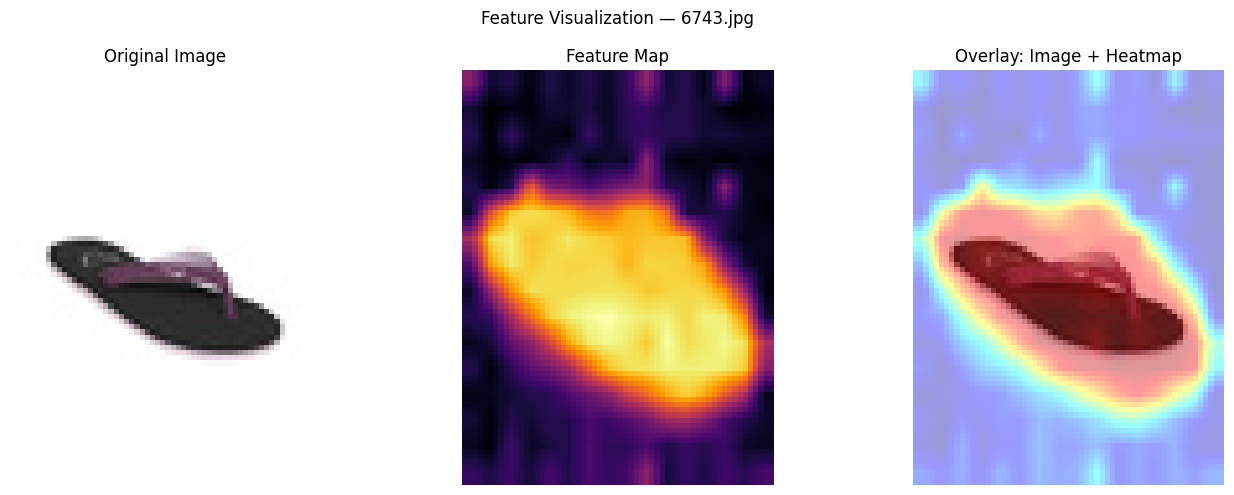

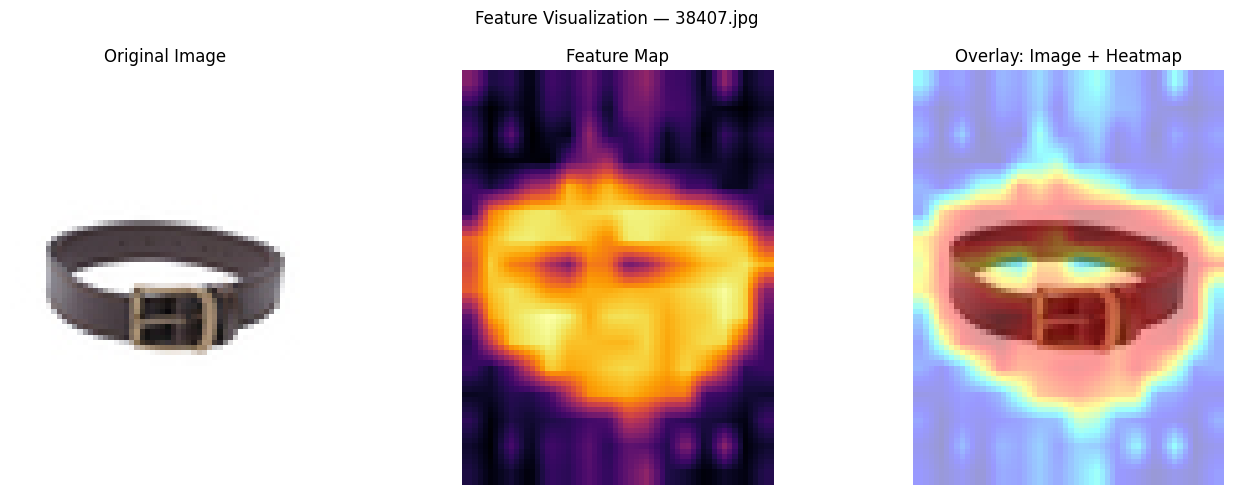

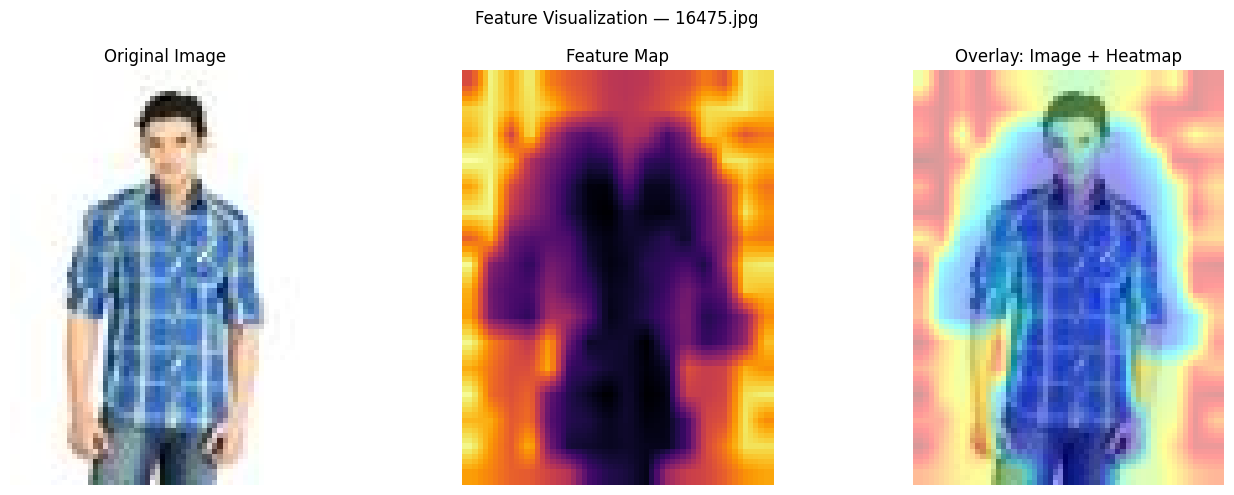

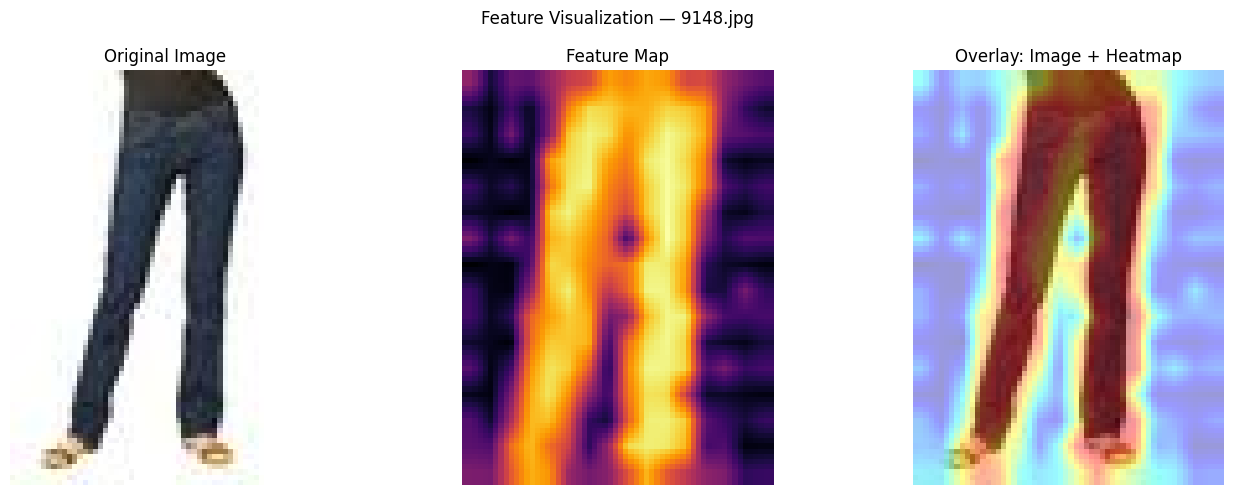

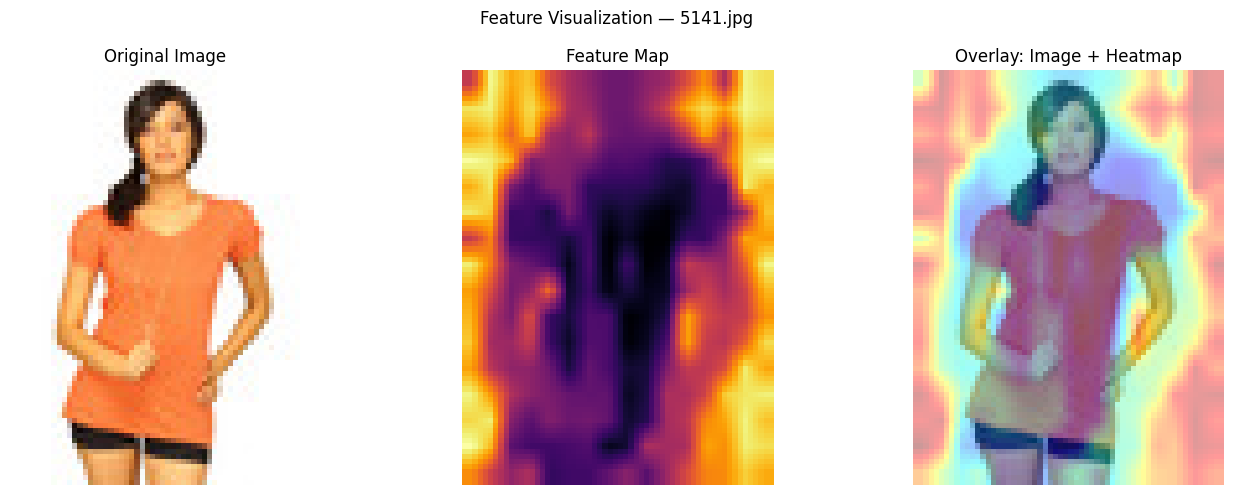

In [14]:

# Load only the small subset
patch_data = np.load("outputs/patch_embeddings_subset.npz", allow_pickle=True)

def get_feature_map_from_embedding(embedding, use_pca=True):
    num_patches = int(embedding.shape[0] ** 0.5)
    fmap = embedding.reshape(num_patches, num_patches, -1)

    if use_pca:
        pca = PCA(n_components=1)
        fmap_2d = pca.fit_transform(fmap.reshape(-1, fmap.shape[-1])).reshape(num_patches, num_patches)
    else:
        fmap_2d = fmap.mean(axis=-1)

    fmap_2d = (fmap_2d - fmap_2d.min()) / (fmap_2d.max() - fmap_2d.min())
    return fmap_2d

def visualize_embedding_heatmap(img_path, embedding, use_pca=True):
    img = Image.open(img_path).convert("RGB")
    fmap = get_feature_map_from_embedding(embedding, use_pca)
    fmap_resized = cv2.resize(fmap, img.size)
    heatmap = cv2.applyColorMap(np.uint8(255 * fmap_resized), cv2.COLORMAP_JET)
    img_cv = np.array(img)[:, :, ::-1]  # RGB → BGR
    overlay = cv2.addWeighted(img_cv, 0.6, heatmap, 0.4, 0)
    overlay_rgb = overlay[:, :, ::-1]  # BGR → RGB
    return img, fmap_resized, overlay_rgb

# Pick random 5 from subset
sample_paths = random.sample(list(patch_data.files), 5)

for img_path in sample_paths:
    embedding = patch_data[img_path]
    img, fmap_resized, overlay = visualize_embedding_heatmap(img_path, embedding)

    fig, axs = plt.subplots(1, 3, figsize=(14, 5))
    axs[0].imshow(img); axs[0].set_title("Original Image"); axs[0].axis("off")
    axs[1].imshow(fmap_resized, cmap="inferno"); axs[1].set_title("Feature Map"); axs[1].axis("off")
    axs[2].imshow(overlay); axs[2].set_title("Overlay: Image + Heatmap"); axs[2].axis("off")
    plt.suptitle(f"Feature Visualization — {os.path.basename(img_path)}")
    plt.tight_layout()
    plt.show()


## Elbow Method


Clustering with different K: 100%|██████████| 48/48 [28:27<00:00, 35.56s/it]


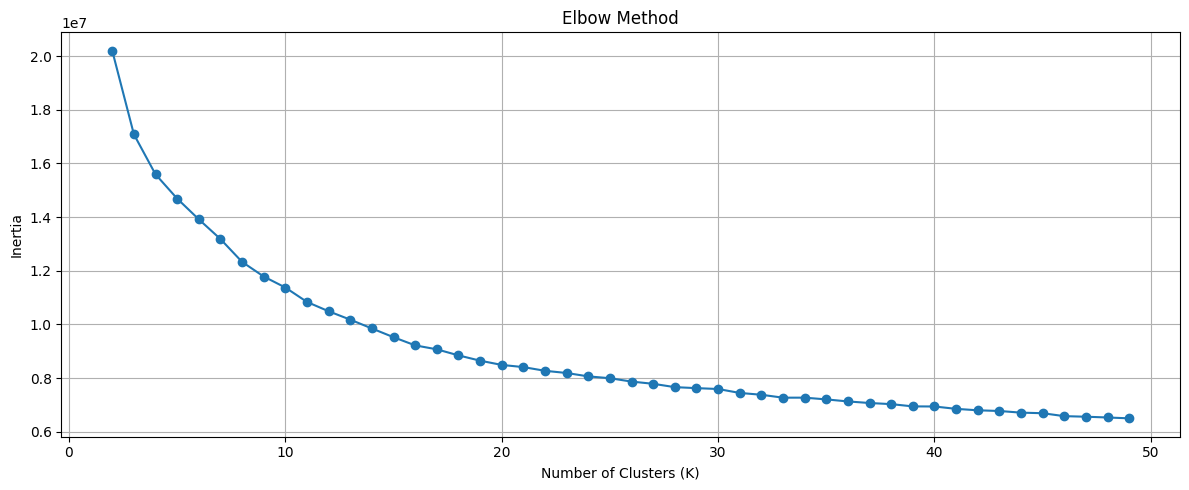

In [15]:
inertias = []

K_RANGE = range(2, 50)                # Range of K for testing

for k in tqdm(K_RANGE, desc="Clustering with different K"):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(all_embeddings)
    inertias.append(kmeans.inertia_)


# Plot Elbow & Silhouette
plt.figure(figsize=(12,5))

plt.plot(list(K_RANGE), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

## Determine Best K

In [16]:
from kneed import KneeLocator

knee = KneeLocator(K_RANGE, inertias, curve="convex", direction="decreasing")
best_k = knee.knee
if best_k is None:
    print("Could not automatically detect elbow; choose visually from plot.")
else:
    print(f"Optimal K determined by Elbow Method: {best_k}")

Optimal K determined by Elbow Method: 16


## K-Means Clustering & Image Segregation

In [17]:
# Configuration
K_FINAL = 16
OUTPUT_DIR = "outputs/clustered_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load embeddings and image paths
all_embeddings = np.load("outputs/embeddings.npy")
image_paths = np.load("outputs/image_paths.npy", allow_pickle=True)

# Run final KMeans
print(f"🔹 Running KMeans with K={K_FINAL}...")
kmeans = KMeans(n_clusters=K_FINAL, random_state=0, n_init=10)
labels = kmeans.fit_predict(all_embeddings)

# Save cluster labels
np.save("outputs/cluster_labels.npy", labels)
print(f" Cluster labels saved: outputs/cluster_labels.npy")

# Segregate images into cluster folders
print("🔹 Saving images into cluster folders...")
for img_path, label in tqdm(zip(image_paths, labels), total=len(image_paths)):
    cluster_dir = os.path.join(OUTPUT_DIR, f"cluster_{label}")
    os.makedirs(cluster_dir, exist_ok=True)
    try:
        img = Image.open(img_path)
        img.save(os.path.join(cluster_dir, os.path.basename(img_path)))
    except Exception as e:
        print(f"Skipped {img_path}: {e}")

print(f" All images segregated into {K_FINAL} clusters at '{OUTPUT_DIR}/'")


🔹 Running KMeans with K=16...
 Cluster labels saved: outputs/cluster_labels.npy
🔹 Saving images into cluster folders...


100%|██████████| 44441/44441 [01:36<00:00, 462.03it/s]

 All images segregated into 16 clusters at 'outputs/clustered_images/'


## Visualise sample images from each cluster

Saved visualization as:
- /kaggle/working/outputs/cluster_visualization.png
- /kaggle/working/outputs/cluster_visualization.pdf


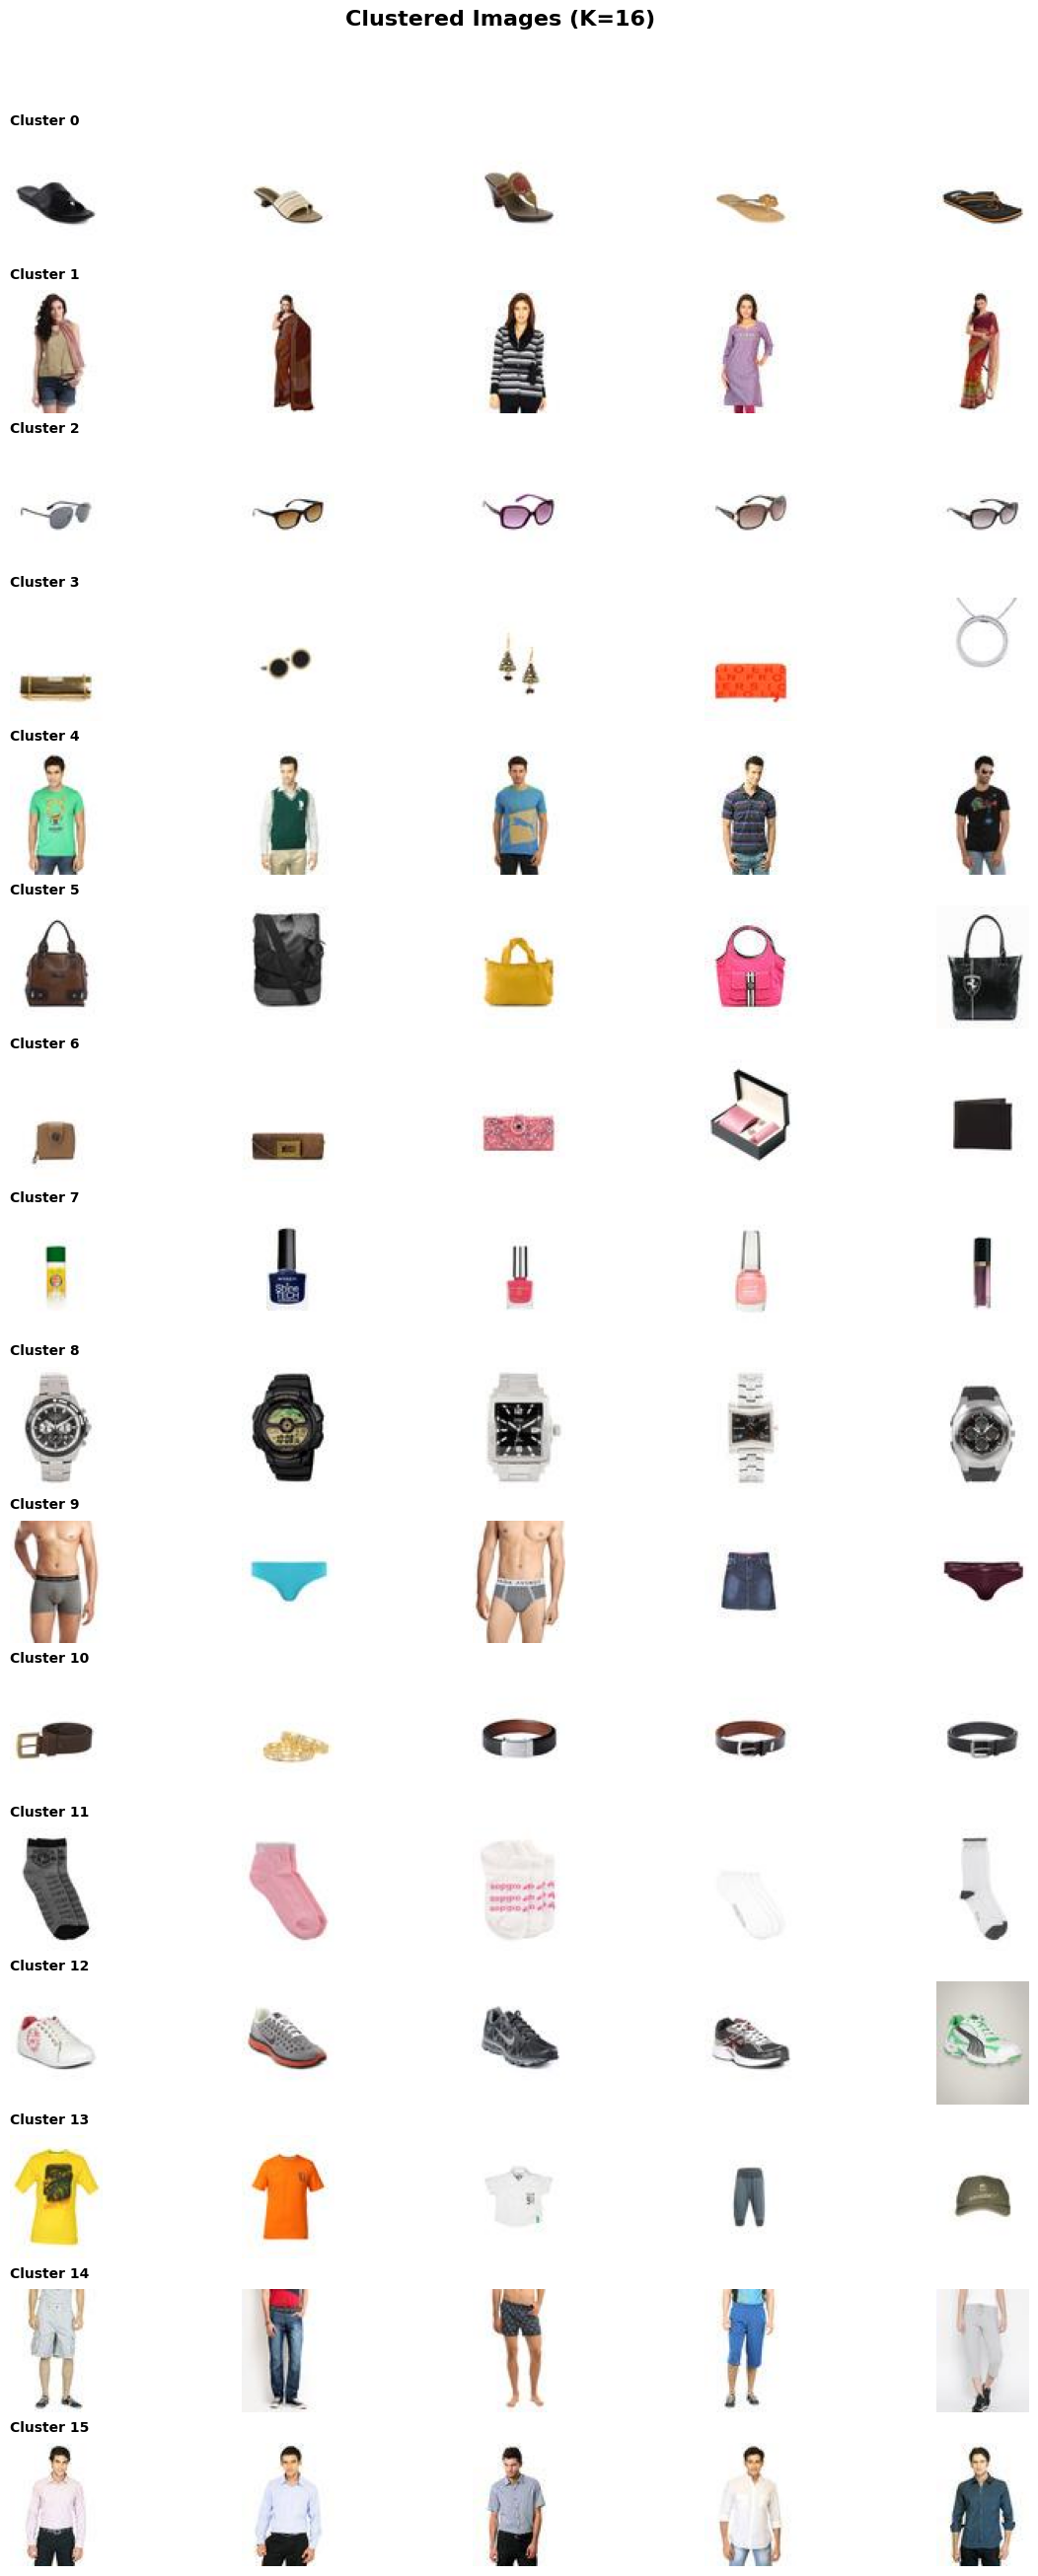

In [28]:
import matplotlib.pyplot as plt
import os, random
from PIL import Image

OUTPUT_DIR = "/kaggle/working/outputs/clustered_images"
SAVE_PATH_PNG = "/kaggle/working/outputs/cluster_visualization.png"
SAVE_PATH_PDF = "/kaggle/working/outputs/cluster_visualization.pdf"
num_samples = 5  # images per cluster

# Collect all cluster directories
cluster_dirs = sorted([d for d in os.listdir(OUTPUT_DIR) if d.startswith("cluster_")])
K_FINAL = len(cluster_dirs)

# Create a figure with K_FINAL rows and num_samples columns
fig, axes = plt.subplots(K_FINAL, num_samples, figsize=(num_samples * 3, K_FINAL * 2))

# Ensure axes is always 2D
if K_FINAL == 1:
    axes = [axes]

for row, cluster_dir in enumerate(cluster_dirs):
    cluster_path = os.path.join(OUTPUT_DIR, cluster_dir)
    images = [os.path.join(cluster_path, f) for f in os.listdir(cluster_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if not images:
        continue

    # Randomly pick up to num_samples images
    sampled = random.sample(images, min(num_samples, len(images)))

    for col in range(num_samples):
        ax = axes[row][col] if K_FINAL > 1 else axes[col]
        ax.axis("off")

        if col < len(sampled):
            img = Image.open(sampled[col])
            ax.imshow(img)
        else:
            ax.imshow(Image.new('RGB', (224, 224), color='white'))  # placeholder

        # Add cluster label to first image in the row
        if col == 0:
            ax.set_title(f"Cluster {row}", fontsize=10, pad=8, loc="left", weight="bold")

# Global title and spacing
plt.suptitle(f"Clustered Images (K={K_FINAL})", fontsize=16, y=0.92, weight="bold")
plt.subplots_adjust(wspace=0.05, hspace=0.25)

# Save plots
plt.savefig(SAVE_PATH_PNG, dpi=500, bbox_inches="tight")
plt.savefig(SAVE_PATH_PDF, dpi=500, bbox_inches="tight")
print(f"Saved visualization as:\n- {SAVE_PATH_PNG}\n- {SAVE_PATH_PDF}")

plt.show()


## Zip & Download

In [24]:
import shutil

shutil.make_archive("/kaggle/working/clustered_images", "zip", "/kaggle/working/outputs/clustered_images")


'/kaggle/working/clustered_images.zip'